In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.5.1


## Download

In [2]:
/bin/rm -rf 2313 12220 
download_chandra_obsid 2313,12220


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  458.5 kb/s
  oif      fits       28 Kb  ####################          < 1 s  565.2 kb/s
  vv       pdf        37 Kb  ####################          < 1 s  1540.4 kb/s
  cntr_img fits      126 Kb  ####################          < 1 s  9003.2 kb/s
  cntr_img jpg       672 Kb  ####################          < 1 s  16907.0 kb/s
  evt2     fits       15 Mb  ####################          < 1 s  34124.8 kb/s
  full_img fits       75 Kb  ####################          < 1 s  7042.3 kb/s
  full_img jpg        54 Kb  ####################          < 1 s  2203.0 kb/s
  bpix     fits       87 Kb  ####################          < 1 s  2718.8 kb/s
  fov      fits        6 Kb  ####################          < 1 s  778.1 kb/s
  eph1     fits      281 Kb  ####################          < 1 s

In [3]:
chandra_repro 2313 out= clob+


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/reproject_aspect/2313'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/reproject_aspect/2313/repro/acisf02313_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/CIAO4.9/reproject_aspect/2313/repro/acisf02313_repro_bpix1.fits
         Run 'punlearn ardlib' when analysis of this dataset completed.

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/re

In [4]:
chandra_repro 12220 out= clob+


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/reproject_aspect/12220'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/reproject_aspect/12220/repro/acisf12220_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/CIAO4.9/reproject_aspect/12220/repro/acisf12220_repro_bpix1.fits
         Run 'punlearn ardlib' when analysis of this dataset completed.

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9

In [5]:
dmkeypar 2313/repro/acisf02313_repro_evt2.fits ONTIME echo+

132129.29851422


In [6]:
dmkeypar 12220/repro/acisf12220_repro_evt2.fits ONTIME echo+

48770.336169183


## Run Wavdetect on obsid 12220

In [7]:
fluximage 12220/repro/acisf12220_repro_evt2.fits cdfs12220 bin=1 \
  band=broad clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution 12220/repro/pcadf393253236N002_asol1.fits found.
Bad-pixel file 12220/repro/acisf12220_repro_bpix1.fits found.
Mask file 12220/repro/acisf12220_000N002_msk1.fits found.

The output images will have 3832 by 3339 pixels, pixel size of 0.492 arcsec,
    and cover x=2604.5:6436.5:1,y=2291.5:5630.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 12220
# DMCOPY (CIAO 4.9): WARNING: Creating large image: 102 MB. Current max set at 50 MB.
Increase maximum using [opt mem=n] or increase blocking to reduce size.
Creating 5 instrument maps for obsid 12220
Creating 5 exposure maps for obsid 12220
Combining 5 exposure maps for obsid 12220
Thresholding data for obsid 12220
Exposure-correcting image for obsid 12220

The following files were created:

 The clipped counts image is:
     cdfs12220_broad_thresh.img

 The clipped exposure map is:
     cdfs12220_broad

In [8]:
mkpsfmap cdfs12220_broad_thresh.img cdfs12220_broad_thresh.psfmap energy=2.3 \
  ecf=0.9 mode=h clob+

In [9]:
punlearn wavdetect
wavdetect \
  infile=cdfs12220_broad_thresh.img \
  psffile=cdfs12220_broad_thresh.psfmap \
  expfile=cdfs12220_broad_thresh.expmap \
  scales="1 2 4 6 8 12 16 24 32" \
  outfile=cdfs12220_broad.src \
  scell=cdfs12220_broad.cell \
  imagefile=cdfs12220_broad.recon \
  defnbkg=cdfs12220_broad.nbkg \
  interdir=./ mode=h clob+

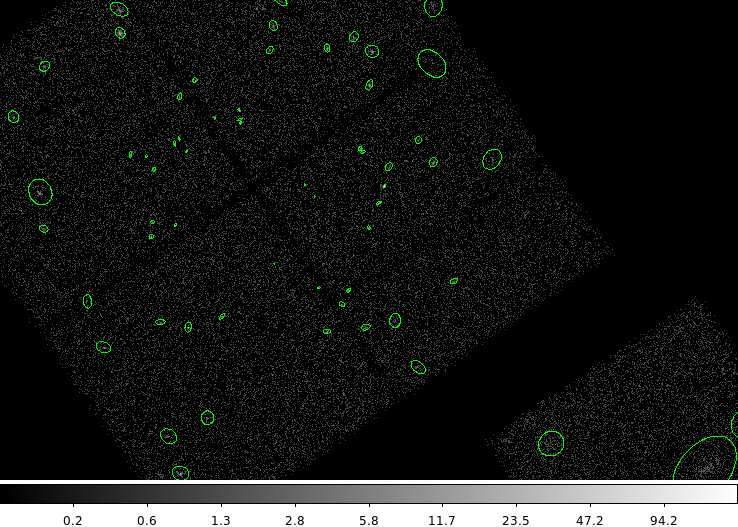

In [52]:
ds9 cdfs12220_broad_thresh.img -scale log -block 4 \
  -region cdfs12220_broad.src \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

## External catalog


In [11]:
cat << EOM > wav12220_point.reg
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
physical
EOM

dmlist "cdfs12220_broad.src[cols x,y]" data,clean | \
grep -v "#" | \
awk '{print "point("$1","$2") # point=cross color=red"}' >> wav12220_point.reg


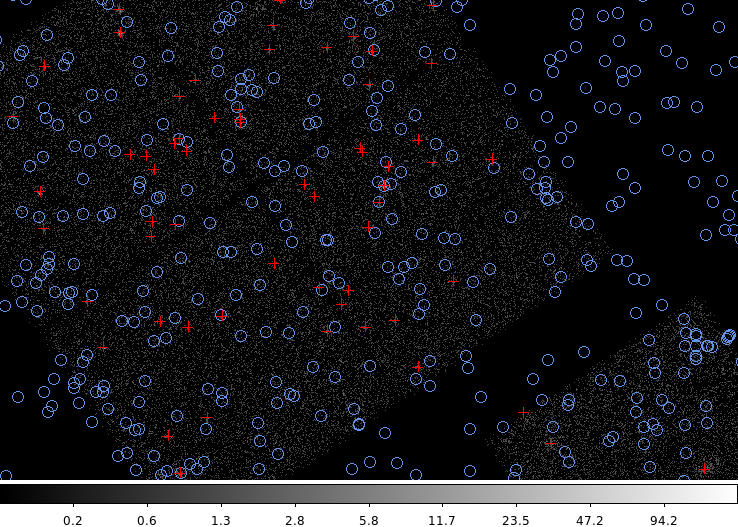

In [53]:
ds9 cdfs12220_broad_thresh.img -block 4 -scale log \
  -catalog ua2 \
  -catalog symbol color cornflowerblue -catalog export tsv usno_a2.tsv  \
  -region wav12220_point.reg \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

In [13]:
head -5 usno_a2.tsv

_RAJ2000	_DEJ2000	USNO-A2.0	RAJ2000	DEJ2000	ACTflag	Mflag	Bmag	Rmag	Epoch
052.663062	-27.791378	0600-01386707	052.663062	-27.791378			20.5	18.2	1983.246
052.666231	-27.905081	0600-01386783	052.666231	-27.905081			14.5	12.8	1983.246
052.667228	-27.822628	0600-01386815	052.667228	-27.822628			20.4	18.2	1983.246
052.667475	-27.907456	0600-01386822	052.667475	-27.907456			18.4	18.0	1983.246


In [14]:
dmlist "usno_a2.tsv[opt skip=1]" cols

 
--------------------------------------------------------------------------------
Columns for Table Block usno_a2.tsv
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   col1                              Real8          -Inf:+Inf            
   2   col2                              Real8          -Inf:+Inf            
   3   col3                              Real8          -Inf:+Inf            
   4   col4                              Real8          -Inf:+Inf            
   5   col5                              Real8          -Inf:+Inf            
   6   col6                              String[4]                           
   7   col7                              String[4]                           
   8   col8                              Real8          -Inf:+Inf            


In [15]:
pset wcs_match infile=cdfs12220_broad.src
pset wcs_match refsrcfile="usno_a2.tsv[opt skip=1][cols ra=col1,dec=col2]"
pset wcs_match outfile=out.xform
pset wcs_match wcsfile=cdfs12220_broad_thresh.img 
pset wcs_match method=trans
wcs_match mode=h clob+


# wcs_match (CIAO 4.9): WARNING: Dup src x_err or ra_err cols not found.  Assuming x_err = 1.
# wcs_match (CIAO 4.9): WARNING: Dup src y_err or dec_err cols not found.  Assuming y_err = 1.


In [16]:
dmlist out.xform cols

 
--------------------------------------------------------------------------------
Columns for Table Block out.xform
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   a11                  n/a          Real8          -Inf:+Inf            Transform Matrix element A11
   2   a12                  n/a          Real8          -Inf:+Inf            Transform Matrix element A12
   3   a21                  n/a          Real8          -Inf:+Inf            Transform Matrix element A21
   4   a22                  n/a          Real8          -Inf:+Inf            Transform Matrix element A22
   5   t1                   n/a          Real8          -Inf:+Inf            Transform Matrix element T1
   6   t2                   n/a          Real8          -Inf:+Inf            Transform Matrix element T2
   7   ra_ref               deg          Real8          -Inf:+Inf            WCS tangent point RA
   8 

In [17]:
dmlist out.xform"[cols a11,a12,a21,a22,t1,t2]" data,clean

#  a11                  a12                  a21                  a22                  t1                   t2
                  1.0                    0                    0                  1.0    -0.34846973186230     0.29613261862157


---
## A 2nd chandra obs

In [18]:
fluximage 2313/repro/acisf02313_repro_evt2.fits cdfs2313 \
  bin=1 band=broad clob+


Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution 2313/repro/pcadf093752813N003_asol1.fits found.
Bad-pixel file 2313/repro/acisf02313_repro_bpix1.fits found.
Mask file 2313/repro/acisf02313_000N003_msk1.fits found.

The output images will have 3989 by 3179 pixels, pixel size of 0.492 arcsec,
    and cover x=1599.5:5588.5:1,y=2548.5:5727.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 2313
# DMCOPY (CIAO 4.9): WARNING: Creating large image: 101 MB. Current max set at 50 MB.
Increase maximum using [opt mem=n] or increase blocking to reduce size.
Creating 5 instrument maps for obsid 2313
Creating 5 exposure maps for obsid 2313
Combining 5 exposure maps for obsid 2313
Thresholding data for obsid 2313
Exposure-correcting image for obsid 2313

The following files were created:

 The clipped counts image is:
     cdfs2313_broad_thresh.img

 The clipped exposure map is:
     cdfs2313_broad_thresh.exp

In [19]:
mkpsfmap cdfs2313_broad_thresh.img cdfs2313_broad_thresh.psfmap \
  energy=2.3 ecf=0.9 mode=h clob+

In [20]:
punlearn wavdetect
wavdetect \
  infile=cdfs2313_broad_thresh.img \
  psffile=cdfs2313_broad_thresh.psfmap \
  expfile=cdfs2313_broad_thresh.expmap \
  scales="1 2 4 6 8 12 16 24 32" \
  outfile=cdfs2313_broad.src \
  scell=cdfs2313_broad.cell \
  imagefile=cdfs2313_broad.recon \
  defnbkg=cdfs2313_broad.nbkg \
  interdir=./ mode=h clob+


In [21]:
cat << EOM > wav2313_point.reg
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
physical
EOM

dmlist "cdfs2313_broad.src[cols x,y]" data,clean | \
grep -v "#" | \
awk '{print "point("$1","$2") # point=cross color=cornflowerblue"}' >> wav2313_point.reg


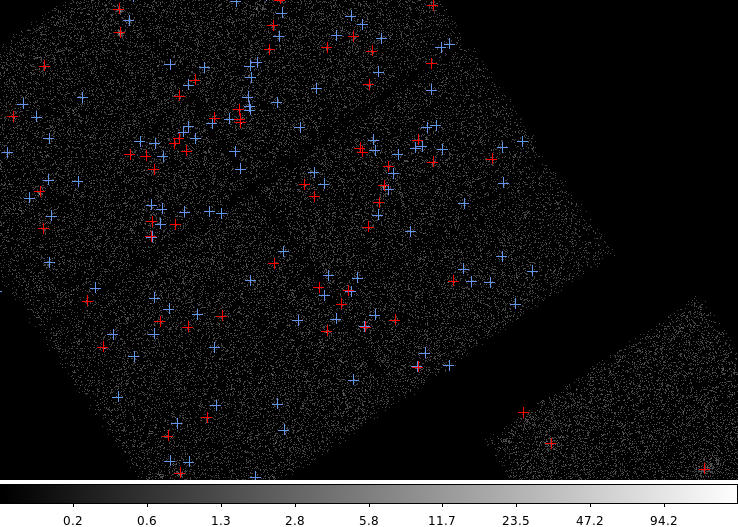

In [22]:
ds9 cdfs12220_broad_thresh.img -block 4 -scale log \
  -region wav12220_point.reg \
  -region wav2313_point.reg \
  -saveimage png ds9_03.png -quit

display < ds9_03.png


In [23]:
pset wcs_match infile=cdfs12220_broad.src
pset wcs_match refsrcfile=cdfs2313_broad.src
pset wcs_match outfile=out.xform
pset wcs_match wcsfile=cdfs12220_broad_thresh.img
pset wcs_match method=trans
wcs_match mode=h clob+

In [24]:
dmlist out.xform"[cols a11,a12,a21,a22,t1,t2]" data,clean

#  a11                  a12                  a21                  a22                  t1                   t2
                  1.0                    0                    0                  1.0     0.22166007944695     0.40545578526692


---

## Apply Corrections

In [25]:
pset wcs_update infile=12220/repro/pcadf393253236N002_asol1.fits
pset wcs_update outfile=pcadf393253236N002_corrected_asol1.fits
pset wcs_update transformfile=out.xform
pset wcs_update wcsfile=cdfs12220_broad_thresh.img
wcs_update mode=h clob+


In [26]:
dmdiff \
   12220/repro/pcadf393253236N002_asol1.fits"[#row=1:3]" \
   pcadf393253236N002_corrected_asol1.fits"[#row=1:3]"  || echo ""

Infile 1:  12220/repro/pcadf393253236N002_asol1.fits[#row=1:3]
Infile 2:  pcadf393253236N002_corrected_asol1.fits[#row=1:3]

-----------------------
HEADER VALUE DIFFERENCES
-----------------------


Message:                                Keyword:              Value(s):                    Diff:
--------                                 -------              ---------                    -----
Values are not equal                    CHECKSUM C6eaC6ZTC6dYC6ZY  VPNAYOK4VOK9VOK9
# dmdiff (CIAO 4.9): WARNING: CHECKSUM comments are different.
# dmdiff (CIAO 4.9):   comment1= "HDU checksum updated 2012-06-28T21:32:25"
# dmdiff (CIAO 4.9):   comment2= "HDU checksum updated 2017-08-10T13:18:02"
Values are not equal                     DATASUM       3985630807  373709006       
# dmdiff (CIAO 4.9): WARNING: DATASUM comments are different.
# dmdiff (CIAO 4.9):   comment1= "data unit checksum updated 2012-06-28T21:13:17"
# dmdiff (CIAO 4.9):   comment2= "data unit checksum updated 2017-08-10T13:18:0

In [27]:
dmcopy 12220/repro/acisf12220_repro_evt2.fits \
  acisf12220_corrected_evt2.fits op=all clob+

In [28]:
pset wcs_update infile=acisf12220_corrected_evt2.fits
pset wcs_update outfile=
wcs_update mode=h clob+

In [29]:
dmdiff \
  12220/repro/acisf12220_repro_evt2.fits \
  acisf12220_corrected_evt2.fits || echo ""

Infile 1:  12220/repro/acisf12220_repro_evt2.fits
Infile 2:  acisf12220_corrected_evt2.fits

-----------------------
HEADER VALUE DIFFERENCES
-----------------------


Message:                                Keyword:              Value(s):                    Diff:
--------                                 -------              ---------                    -----
Values are not equal                    CHECKSUM 1q2Q4o0Q1o0Q1o0Q  6WJk8TGi6TGi6TGi
# dmdiff (CIAO 4.9): WARNING: CHECKSUM comments are different.
# dmdiff (CIAO 4.9):   comment1= "HDU checksum updated 2017-08-10T12:54:24"
# dmdiff (CIAO 4.9):   comment2= "HDU checksum updated 2017-08-10T13:18:06"
# dmdiff (CIAO 4.9): WARNING: DATASUM comments are different.
# dmdiff (CIAO 4.9):   comment1= "data unit checksum updated 2017-08-10T12:54:18"
# dmdiff (CIAO 4.9):   comment2= "data unit checksum updated 2017-08-10T13:18:05"
Values are not equal                      RA_PNT  53.111268606605  53.111234359143  -3.42475e-05
Values are not e

In [30]:
dmlist 12220/repro/acisf12220_repro_evt2.fits header,clean,raw | grep CRVL

TCRVL5       = 0                    /                     
TCRVL6       = 0                    /                     
TCRVL9       = 0                    /                     
TCRVL10      = 0                    /                     
TCRVL11      =      53.11126861     /                     
TCRVL12      =     -27.80403466     /                     


In [31]:
dmlist acisf12220_corrected_evt2.fits header,clean,raw | grep CRVL

TCRVL5       = 0                    /                     
TCRVL6       = 0                    /                     
TCRVL9       = 0                    /                     
TCRVL10      = 0                    /                     
TCRVL11      =      53.11123436     /                     
TCRVL12      =     -27.80397925     /                     


In [32]:
dmhedit acisf12220_corrected_evt2.fits file= op=add key=ASOLFILE \
  value=pcadf393253236N002_corrected_asol1.fits

In [33]:
dmcopy cdfs2313_broad_flux.img cdfs2313_broad_flux.corrected.img op=all clob+

In [34]:
wcs_update cdfs2313_broad_flux.corrected.img outfile= trans=out.xform wcsfile=cdfs2313_broad_flux.img

---

## User offsets

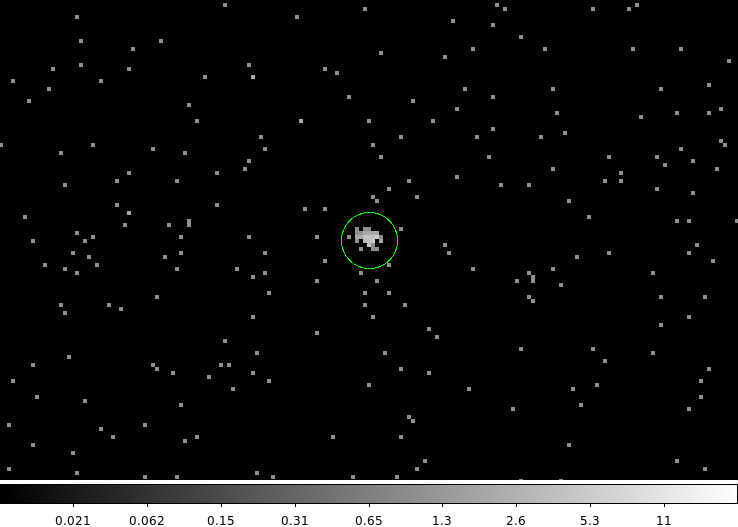

In [35]:
ds9 cdfs12220_broad_thresh.img -zoom 4 -pan to 3798 3612 physical \
  -regions command "physical;circle(3798,3612,7)" -scale log \
  -saveimage png ds9_04.png -quit 

display < ds9_04.png

In [36]:
dmstat cdfs12220_broad_thresh.img"[sky=circle(3798,3612,7)]" cen+ sig- med-

EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 3798 3605 )
    max:	6 	      @:	( 3800 3613 )
cntrd[log] :	( 8.0333333333 8.7 )
cntrd[phys]:	( 3798.0333333 3612.7 )
   good:	149 
   null:	76 


In [37]:
punlearn dmcoords
dmcoords cdfs12220_broad_thresh.img op=sky x=3798.03 y=3612.7 verb=0 celfmt=deg 
pget dmcoords ra dec

53.15741163457621
-27.87014629033254


In [38]:
prop_precess f j/deg t j/hms eval 53.1574116345 -27.87014629033254

Precess [Conversion mode]
Enter "q" to return to setup mode
--------------------------------------------------------------------------------
RA,Dec J2000.0                   53.157412   -27.870146
RA,Dec J2000.0                  03 32 37.78 -27 52 12.53
--------------------------------------------------------------------------------


### To coordinates

In [39]:
prop_precess from j/hms to j/deg p0 eval 03 32 38.0 -27 52 13.0

 53.158333   -27.870278


In [40]:
punlearn dmcoords
dmcoords cdfs12220_broad_thresh.img op=cel celfmt=hms ra=03:32:38.0 dec=-27:52:13.0 verb=0
pget dmcoords x y


3792.068481813161
3611.735628354206


### Let wcs_match do it

In [41]:
cat << EOM > obs.dat
#ra dec
53.15741163457621 -27.87014629033254
EOM


In [42]:
cat << EOM > usr.dat
#ra dec
53.158333   -27.870278
EOM

In [43]:
wcs_match in=obs.dat ref=usr.dat out=manual.xform wcs=cdfs12220_broad_thresh.img  clob+ method=trans verb=1

 input (dup) src file : obs.dat
 input ref src file   : usr.dat
 input wcsfile        : cdfs12220_broad_thresh.img
 debug level          : 1

1 common sources found between: 
usr.dat
obs.dat
After deleting poor matches, 1 sources remain

Source Residuals
----------------
 Ref#  Dup#    Ref RA      Ref Dec.    Prior  Transfm  Resid Incl
                                       Resid  Resid    Ratio
   0     0     53.15833   -27.87028    0.49    0.00    0.00    Y

Source Residuals, before/after transform (arcsec), and percentage improvement:

   Average Residuals:         0.000000   0.000000    -nan%
   Maximum Residuals:         0.492000   0.000000  100.00%

Source Residual Ratios, before/after transform, and percentage improvement:

   Average Residual Ratios:   0.000000   0.000000    -nan%
   Maximum Residual Ratios:   0.500000   0.000000  100.00%

# wcs_match (CIAO 4.9): WARNING: Dup src x_err or ra_err cols not found.  Assuming x_err = 1.
# wcs_match (CIAO 4.9): WARNING: Dup src y_err

In [44]:
dmlist manual.xform data,clean 

#  a11                  a12                  a21                  a22                  t1                   t2                   ra_ref               dec_ref              roll_ref             xpix_ref             ypix_ref             x_scale              y_scale
                  1.0                    0                    0                  1.0        -5.9593614438    -0.96599683669365        53.1112686066       -27.8040346647                    0              4096.50              4096.50     -0.0001366666667      0.0001366666667


In [45]:
dmcopy cdfs12220_broad_thresh.img cdfs12220_broad_thresh.img.manual clob+
wcs_update cdfs12220_broad_thresh.img.manual none trans=manual.xform wcsfile=")infile" 

In [46]:
dmstat cdfs12220_broad_thresh.img"[sky=circle(3798,3612,7)]" cen+ sig- med-

EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 3798 3605 )
    max:	6 	      @:	( 3800 3613 )
cntrd[log] :	( 8.0333333333 8.7 )
cntrd[phys]:	( 3798.0333333 3612.7 )
   good:	149 
   null:	76 


In [47]:
punlearn dmcoords
dmcoords cdfs12220_broad_thresh.img.manual op=sky x=3798.03 y=3612.7 verb=0 celfmt=hms
pget dmcoords ra dec

03:32:37.999
-27:52:13.00


### Use offset parameters

Use compute the offsets as :  $ref - obs$

In [48]:
echo 3792.070638556241 - 3798.0333333 | bc -l
echo 3611.734003163342 -  3612.7 | bc -l


-5.962694743759
-.965996836658


In [49]:
dmcopy cdfs12220_broad_thresh.img cdfs12220_broad_thresh.img.manual_offsets clob+
wcs_update cdfs12220_broad_thresh.img.manual_offsets none trans= wcsfile=")infile" deltax=-5.962694743759 deltay=-.965996836658

In [50]:
dmstat cdfs12220_broad_thresh.img"[sky=circle(3798,3612,7)]" cen+ sig- med-

EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 3798 3605 )
    max:	6 	      @:	( 3800 3613 )
cntrd[log] :	( 8.0333333333 8.7 )
cntrd[phys]:	( 3798.0333333 3612.7 )
   good:	149 
   null:	76 


In [51]:
punlearn dmcoords
dmcoords cdfs12220_broad_thresh.img.manual op=sky x=3798.03 y=3612.7 verb=0 celfmt=hms 
pget dmcoords ra dec

03:32:37.999
-27:52:13.00
